# t1t2_component_detection — End-to-end demo

A local walk-through of the from-scratch **T1–T2 Detection Transformer** pipeline:

**protocol → signal → model → short training demo → evaluation**

Runs on the small `data/dev/` split. **This is a smoke demo on CPU, not the thesis training
run — that happens on the GPU cluster.** The point is to show every piece connects and the
model learns.

In [8]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

# locate the repo root whether we run from notebooks/ or the package root
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "voxel_generator" / "src"))
torch.manual_seed(0); np.random.seed(0)

from t1t2.device import get_device, device_info
print("root  :", ROOT.name)
print("device:", get_device(None), "|", device_info())

root  : t1t2_component_detection
device: cpu | cpu


## 1. The acquisition protocol
The fixed 8 TI × 8 TE = 64-point scanner schedule, used exactly as stored (scanner order).

In [9]:
from t1t2.physics import load_protocol
proto = load_protocol()
print(f"{proto.n_points} points | {len(np.unique(proto.ti))} TI x {len(np.unique(proto.te))} TE | TR = {proto.tr:.0f} ms")
print("unique TI (ms):", np.round(np.unique(proto.ti), 1))
print("unique TE (ms):", np.round(np.unique(proto.te), 1))

64 points | 8 TI x 8 TE | TR = 20000 ms
unique TI (ms): [  50.   85.  143.  243.  412.  697. 1181. 2000.]
unique TE (ms): [  4.5   7.5  12.   20.   33.   55.   91.  150. ]


## 2. One voxel: signed signal + ground-truth compartments
The 64 scanner-ordered points are folded back into an 8×8 (TI×TE) grid for display. Note the
**negative (red) values** — the inversion-recovery signal genuinely goes negative, which is
why the data is signed and the noise model is Gaussian, not Rician.

In [10]:
df = pd.read_parquet(ROOT / "data" / "dev" / "train.parquet")
row = df.iloc[7]
S = row[[f"S_{i+1}" for i in range(64)]].to_numpy(float)
n = int(row.n_comp)
comps = [(row[f"T1_{i+1}"], row[f"T2_{i+1}"], row[f"w_{i+1}"]) for i in range(n)]
print("n_comp:", n)
for i, (t1, t2, w) in enumerate(comps):
    print(f"  comp {i+1}: T1={t1:7.1f} ms   T2={t2:6.1f} ms   w={w:.3f}")

uti, ute = np.unique(proto.ti), np.unique(proto.te)
img = np.full((8, 8), np.nan)
for p in range(64):
    i = int(np.argmin(abs(uti - proto.ti[p])))
    j = int(np.argmin(abs(ute - proto.te[p])))
    img[i, j] = S[p]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
m = np.nanmax(np.abs(img))
im = ax[0].imshow(img, cmap="RdBu", vmin=-m, vmax=m, aspect="auto")
ax[0].set_xticks(range(8)); ax[0].set_xticklabels([f"{t:.0f}" for t in ute], rotation=45)
ax[0].set_yticks(range(8)); ax[0].set_yticklabels([f"{t:.0f}" for t in uti])
ax[0].set_xlabel("TE (ms)"); ax[0].set_ylabel("TI (ms)")
ax[0].set_title("Signed signal, 8 TI x 8 TE  (red = negative)")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].scatter([c[1] for c in comps], [c[0] for c in comps],
              s=[400 * c[2] for c in comps], c="crimson", edgecolor="k", zorder=3)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlim(5, 4000); ax[1].set_ylim(50, 5000)
ax[1].set_xlabel("T2 (ms)"); ax[1].set_ylabel("T1 (ms)")
ax[1].set_title("Ground-truth compartments (marker size ~ weight)")
plt.tight_layout(); plt.show()

n_comp: 2
  comp 1: T1= 2549.5 ms   T2= 629.7 ms   w=0.947
  comp 2: T1=  134.1 ms   T2=  13.4 ms   w=0.053


/var/folders/n2/v7krv3hd7f9_j02wpl4_74000000gn/T/ipykernel_43281/1845167849.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 3. The model
MLP encoder → 10 learned queries → transformer decoder → per-query (T1, T2, w, existence).

In [11]:
from t1t2.config import load_config
from t1t2.model import build_model
cfg = load_config(ROOT / "configs" / "baseline.yaml")
model = build_model(cfg.model)
nparams = sum(p.numel() for p in model.parameters())
print(f"T1T2DETR: {nparams/1e6:.2f}M params | {cfg.model.n_queries} queries x 4 outputs (T1, T2, w, exist)")

X = torch.from_numpy(df[[f"S_{i+1}" for i in range(64)]].to_numpy(np.float32)[:4])
out = model(X)
print("forward:", tuple(X.shape), "->", tuple(out.shape), "= (batch, queries, [T1,T2,w,exist_logit])")

T1T2DETR: 4.51M params | 10 queries x 4 outputs (T1, T2, w, exist)
forward: (4, 64) -> (4, 10, 4) = (batch, queries, [T1,T2,w,exist_logit])


## 4. Short training demo
A quick CPU run on 1,200 voxels for 20 epochs — just enough to watch the Hungarian loss fall.
The real run uses 1M voxels on a GPU; here we only prove the loop learns.

In [12]:
from t1t2.config import ExperimentConfig, DataConfig, ModelConfig, LossConfig, TrainConfig
from t1t2.train import train

demo_cfg = ExperimentConfig(
    name="demo",
    data=DataConfig(train_path=str(ROOT / "data" / "dev" / "train.parquet"),
                    val_path=str(ROOT / "data" / "dev" / "val.parquet")),
    model=ModelConfig(), loss=LossConfig(),
    train=TrainConfig(epochs=20, batch_size=128, lr=3e-4, ckpt_every=999),
)
hist, rd, model = train(demo_cfg, results_dir=ROOT / "results" / "demo",
                        max_epochs=20, limit=1200, resume=False, log=lambda *a: None)

tr = [h["train"]["loss"] for h in hist]
va = [h["val"]["loss"] for h in hist]
plt.figure(figsize=(6, 4))
plt.plot(tr, "o-", label="train", ms=3)
plt.plot(va, "s-", label="val", ms=3)
plt.xlabel("epoch"); plt.ylabel("Hungarian loss")
plt.title("Short training demo (1,200 voxels, 20 epochs, CPU)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"train loss {tr[0]:.3f} -> {tr[-1]:.3f}   |   val loss {va[0]:.3f} -> {va[-1]:.3f}")

train loss 0.174 -> 0.045   |   val loss 0.111 -> 0.047


/var/folders/n2/v7krv3hd7f9_j02wpl4_74000000gn/T/ipykernel_43281/2107271646.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.legend(); plt.tight_layout(); plt.show()


## 5. Evaluation
Metrics on held-out test voxels, plus the predicted-vs-true (T1,T2) scatter. The model is
deliberately under-trained here, so numbers are modest — the pipeline, not the accuracy, is
the deliverable. CSF-T2 is reported separately (weakly identifiable at TE_max ≈ 150 ms).

{
  "n_voxels": 1000,
  "n_matched": 1949,
  "count_accuracy": 0.464,
  "count_mae": 0.601,
  "t1_rel_median": 0.266,
  "t2_rel_median": 0.365,
  "t1_mae_ms": 109.564,
  "t2_mae_ms": 16.099,
  "w_mae": 0.093,
  "t2_rel_median_noncsf": 0.355,
  "t2_rel_median_csf": 0.569
}


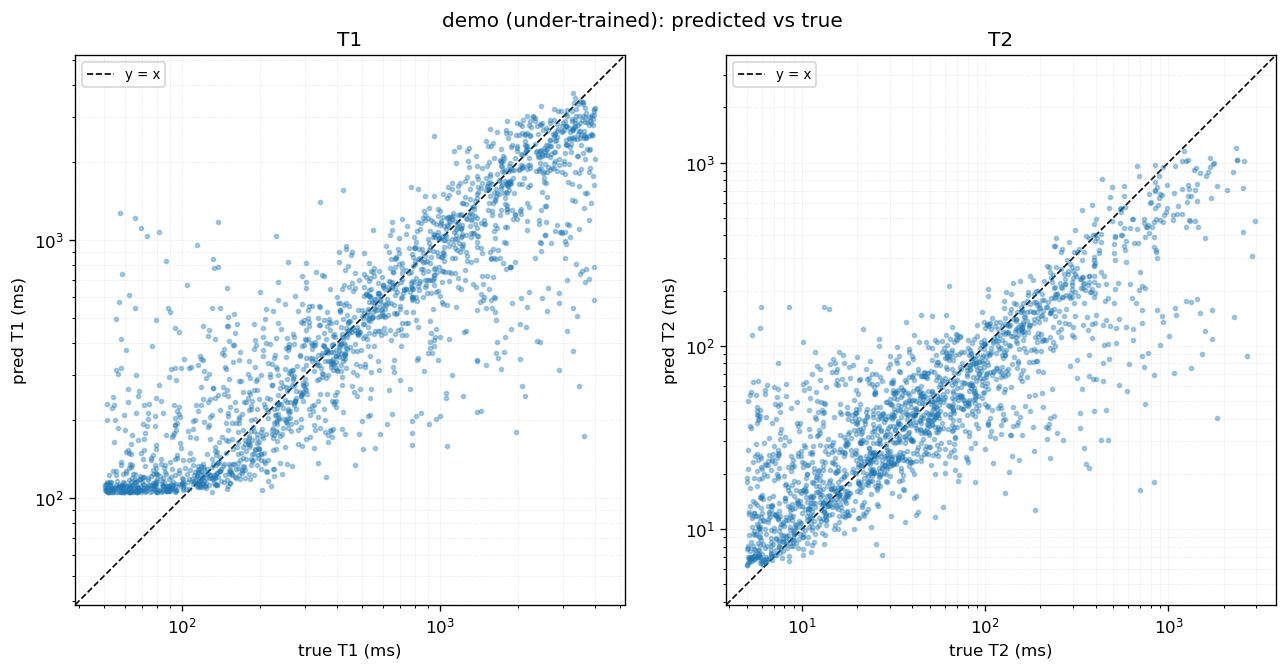

In [13]:
from t1t2.data import VoxelDataset, TargetNormalizer
from t1t2.eval import detr_predictions, true_compartments, compute_metrics, scatter_figure
import json

nz = TargetNormalizer.from_config(demo_cfg.data)
ds = VoxelDataset(str(ROOT / "data" / "dev" / "test.parquet"), demo_cfg.data, nz, limit=1000)
preds = detr_predictions(model, ds, get_device(None), nz)
trues = true_compartments(ds)
metrics = compute_metrics(preds, trues)
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in metrics.items()}, indent=2))

path = scatter_figure(preds, trues, ROOT / "results" / "demo" / "figures" / "scatter_demo.png",
                      title="demo (under-trained): predicted vs true")
from IPython.display import Image
Image(filename=str(path))

## 5b. Predicted vs ground-truth compartments — overlaid in (T1,T2) + existence scores
The key view: are the **red** predicted markers (existence > 0.5) near the **black** true ones?
**Grey ×** are queries the model rejected (existence ≤ 0.5); the red numbers are existence
probabilities; marker size ~ weight.

voxels predicting >=1 compartment : 100.0%
mean predicted count              : 2.50   (mean true 2.00)
mean of each voxel's top existence: 0.975


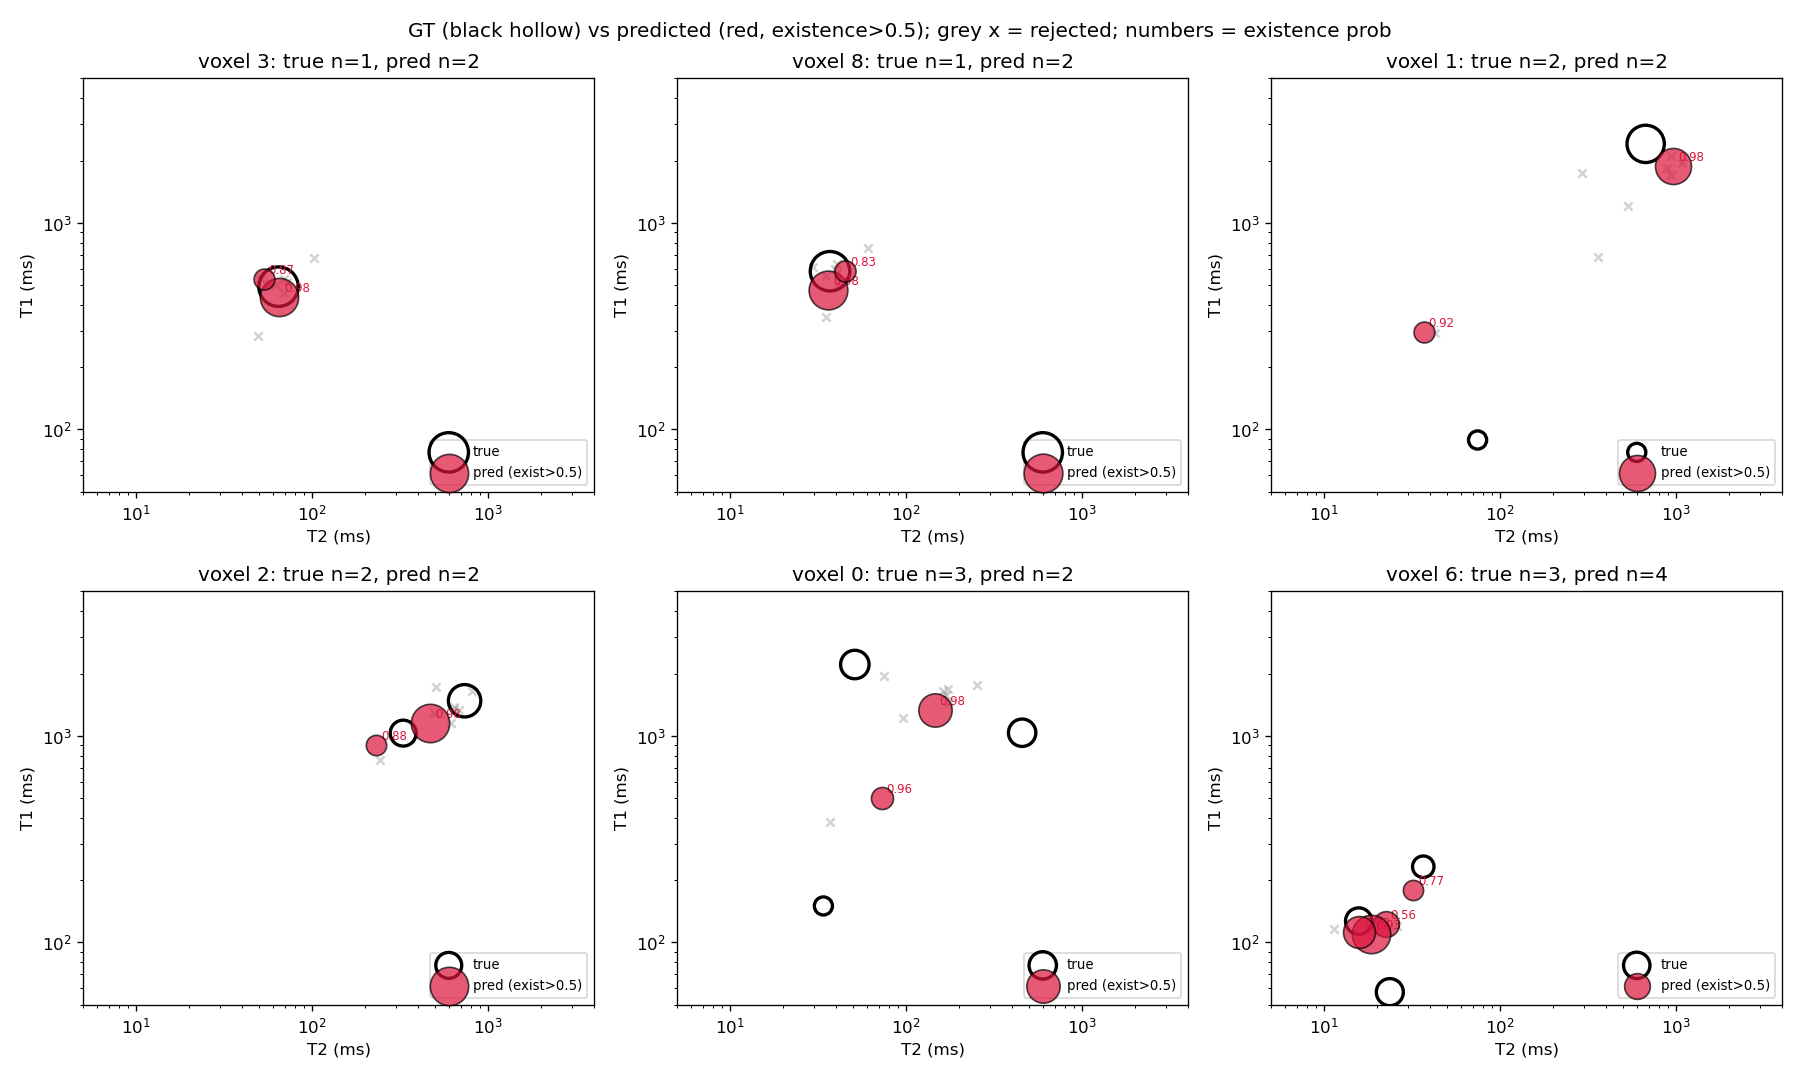

In [14]:
with torch.no_grad():
    raw = model(ds.X).numpy()                       # (N, 10, 4) — all queries
exist = 1.0 / (1.0 + np.exp(-raw[:, :, 3]))
t1p = nz.denormalize_t1(raw[:, :, 0]); t2p = nz.denormalize_t2(raw[:, :, 1]); wp = raw[:, :, 2]
nc = ds.n_comp.numpy()
n_pred = (exist > 0.5).sum(axis=1)
print(f"voxels predicting >=1 compartment : {(n_pred >= 1).mean()*100:.1f}%")
print(f"mean predicted count              : {n_pred.mean():.2f}   (mean true {nc.mean():.2f})")
print(f"mean of each voxel's top existence: {exist.max(axis=1).mean():.3f}")

idxs = []
for tn in (1, 2, 3):
    idxs += np.where(nc == tn)[0][:2].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, i in zip(axes.ravel(), idxs):
    keep = exist[i] > 0.5
    for j in range(int(nc[i])):
        ax.scatter(ds.raw_t2[i, j], ds.raw_t1[i, j], s=60 + 500 * ds.raw_w[i, j],
                   facecolors="none", edgecolors="black", linewidths=2, zorder=3,
                   label="true" if j == 0 else None)
    kq = np.where(keep)[0]
    for q in kq:
        ax.scatter(t2p[i, q], t1p[i, q], s=60 + 500 * wp[i, q], c="crimson", alpha=0.7,
                   edgecolors="k", zorder=4, label="pred (exist>0.5)" if q == kq[0] else None)
        ax.annotate(f"{exist[i, q]:.2f}", (t2p[i, q], t1p[i, q]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="crimson")
    for q in np.where(~keep)[0]:
        ax.scatter(t2p[i, q], t1p[i, q], s=25, c="grey", alpha=0.35, marker="x", zorder=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(5, 4000); ax.set_ylim(50, 5000)
    ax.set_xlabel("T2 (ms)"); ax.set_ylabel("T1 (ms)")
    ax.set_title(f"voxel {i}: true n={int(nc[i])}, pred n={int(keep.sum())}")
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("GT (black hollow) vs predicted (red, existence>0.5); grey x = rejected; numbers = existence prob")
fig.tight_layout()
# an earlier cell imported eval, which sets matplotlib to the Agg backend, so plt.show() would
# render nothing here; save + display via Image instead (same trick as the scatter above)
_ovp = ROOT / "results" / "demo" / "figures" / "overlay_pred_vs_true.png"
fig.savefig(_ovp, dpi=120); plt.close(fig)
from IPython.display import Image
Image(filename=str(_ovp))

## 5c. The same voxels as numbers
The overlay above, printed to the terminal: for each example voxel, the **ground-truth**
compartments (T1, T2, weight) and the model's **predicted** compartments — every query it kept
(existence > 0.5), with its T1, T2, weight and existence score. Both lists are sorted strongest-first
(GT by weight, predictions by existence) so you can read off pairs by eye.

In [15]:
# The same six example voxels as the overlay above, but printed as numbers.
# For each: ground-truth compartments, then the model's kept queries (existence > 0.5),
# each sorted by weight / existence so the strongest come first.
with torch.no_grad():
    raw = model(ds.X).numpy()                       # (N, 10, 4)
exist = 1.0 / (1.0 + np.exp(-raw[:, :, 3]))         # existence probability per query
t1p = nz.denormalize_t1(raw[:, :, 0])               # back to ms
t2p = nz.denormalize_t2(raw[:, :, 1])
wp = raw[:, :, 2]                                    # weight in [0, 1]
nc = ds.n_comp.numpy()

idxs = []
for tn in (1, 2, 3):
    idxs += np.where(nc == tn)[0][:2].tolist()

for i in idxs:
    keep = np.where(exist[i] > 0.5)[0]
    keep = keep[np.argsort(-exist[i, keep])]        # strongest existence first
    print(f"\n=== voxel {i}:  true n_comp = {int(nc[i])}   |   predicted (exist>0.5) = {len(keep)} ===")
    print("  ground truth:")
    gt = sorted(range(int(nc[i])), key=lambda j: -ds.raw_w[i, j])
    for j in gt:
        print(f"    T1={ds.raw_t1[i, j]:8.1f} ms   T2={ds.raw_t2[i, j]:7.1f} ms   w={ds.raw_w[i, j]:.3f}")
    print("  predicted:")
    if len(keep) == 0:
        top = int(np.argmax(exist[i]))
        print(f"    (none kept; best query exist={exist[i, top]:.3f} "
              f"T1={t1p[i, top]:.1f} T2={t2p[i, top]:.1f} w={wp[i, top]:.3f})")
    for q in keep:
        print(f"    T1={t1p[i, q]:8.1f} ms   T2={t2p[i, q]:7.1f} ms   w={wp[i, q]:.3f}   exist={exist[i, q]:.3f}")



=== voxel 3:  true n_comp = 1   |   predicted (exist>0.5) = 2 ===
  ground truth:
    T1=   490.6 ms   T2=   64.4 ms   w=1.000
  predicted:
    T1=   439.5 ms   T2=   65.1 ms   w=0.932   exist=0.982
    T1=   536.4 ms   T2=   53.0 ms   w=0.194   exist=0.867

=== voxel 8:  true n_comp = 1   |   predicted (exist>0.5) = 2 ===
  ground truth:
    T1=   582.8 ms   T2=   36.9 ms   w=1.000
  predicted:
    T1=   472.5 ms   T2=   36.1 ms   w=0.959   exist=0.982
    T1=   585.9 ms   T2=   44.9 ms   w=0.201   exist=0.830

=== voxel 1:  true n_comp = 2   |   predicted (exist>0.5) = 2 ===
  ground truth:
    T1=  2409.7 ms   T2=  671.3 ms   w=0.883
    T1=    88.8 ms   T2=   74.4 ms   w=0.117
  predicted:
    T1=  1884.7 ms   T2=  957.5 ms   w=0.816   exist=0.980
    T1=   294.7 ms   T2=   36.7 ms   w=0.194   exist=0.919

=== voxel 2:  true n_comp = 2   |   predicted (exist>0.5) = 2 ===
  ground truth:
    T1=  1477.4 ms   T2=  735.1 ms   w=0.636
    T1=  1030.1 ms   T2=  329.1 ms   w=0.364
  pre

## Summary
- The whole pipeline runs end to end: **protocol → signed 64-pt signal → DETR → Hungarian loss
  → evaluation**.
- The forward model matches the data generator bit-for-bit (parity-tested), so the training
  targets and the physics speak exactly the same language.